In [2]:
# Import the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Import the dataset
train = pd.read_csv('../data/raw/train.csv')
test = pd.read_csv('../data/raw/test.csv')

# Data PreProcessing

In [4]:
# Shapes of the datasets
print("Train shape: ",train.shape)
print("Test shape: ",test.shape)


Train shape:  (1460, 81)
Test shape:  (1459, 80)


In [5]:
# Finding out about train dataset
train.head()
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## EDA (Exploratory Data Analysis)

In [6]:
# Handling the missing values in train dataset
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending = False)
missing_pct = (missing/len(train)) * 100  # FInding the missing percentage

missing_df = pd.DataFrame({'Missing Count':missing,'Missing %':missing_pct.round(2)})
print(missing_df)

              Missing Count  Missing %
PoolQC                 1453      99.52
MiscFeature            1406      96.30
Alley                  1369      93.77
Fence                  1179      80.75
MasVnrType              872      59.73
FireplaceQu             690      47.26
LotFrontage             259      17.74
GarageType               81       5.55
GarageYrBlt              81       5.55
GarageFinish             81       5.55
GarageQual               81       5.55
GarageCond               81       5.55
BsmtExposure             38       2.60
BsmtFinType2             38       2.60
BsmtQual                 37       2.53
BsmtCond                 37       2.53
BsmtFinType1             37       2.53
MasVnrArea                8       0.55
Electrical                1       0.07


##### This missing_df shows that total columns are 81 but 19 out of 81 are having the missing values. This data does not tells that the data is incomplete but indicates the absence of the features.

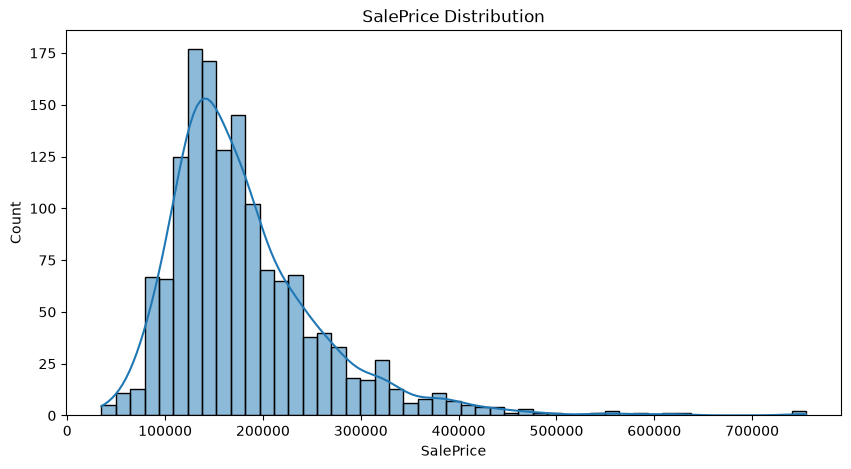

Skewness:  1.8812964895244009


count      1458.000000
mean     180932.919067
std       79495.055285
min       34900.000000
25%      129925.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [46]:
# Getting info about SalePrice columns 
plt.figure(figsize=(10,5))
sns.histplot(train['SalePrice'],kde=True)
plt.title('SalePrice Distribution')
plt.savefig('../reports/figures/saleprice_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Skewness: ",train['SalePrice'].skew())

train['SalePrice'].describe()

##### After conducting the Analysis on SalePrice it is shown that it is right skewed with skewness of 1.8828. The Histogram shows that concentration of the houses in the 100K-250K range with a long tail extending toward higher-prices Property. 

In [8]:
# Correlation with SalePrice
numeric_cols = train.select_dtypes(include=[np.number])
correlations =numeric_cols.corr()['SalePrice'].sort_values(ascending = False)
print(correlations)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

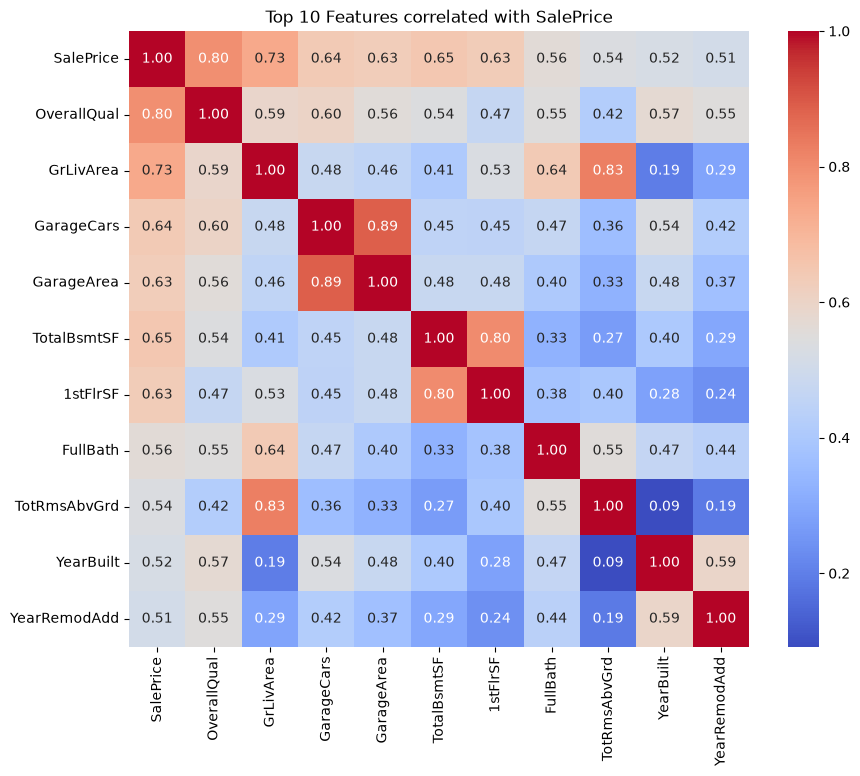

In [47]:
# Visualise top correlated features in Heatmap
top_features = correlations.head(11).index
plt.figure(figsize=(10,8))
sns.heatmap(train[top_features].corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Top 10 Features correlated with SalePrice")
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

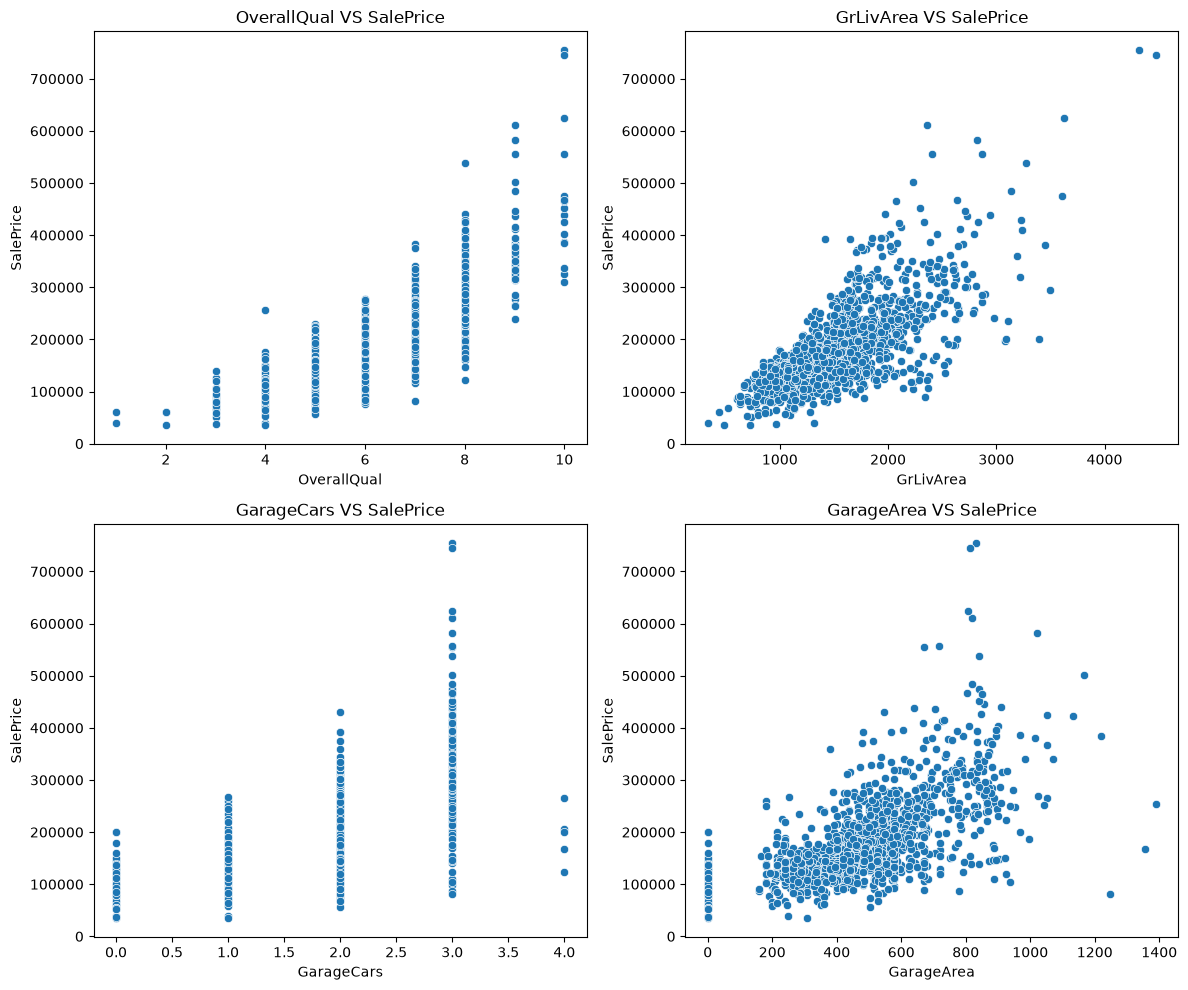

In [48]:
# Scatterplot for 4 features at top VS SalePrice
top_4 = correlations.index[1:5]
fig, axes = plt.subplots(2,2,figsize=(12,10))
for ax,col in zip(axes.flatten(),top_4):
    sns.scatterplot(x=train[col],y=train['SalePrice'],ax=ax)
    ax.set_title(f'{col} VS SalePrice')
plt.tight_layout()
plt.savefig('../reports/figures/top_features_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train[train['GarageArea'] > 1200][['GarageArea', 'SalePrice', 'GrLivArea', 'OverallQual']]

,GarageArea,SalePrice,GrLivArea,OverallQual
581,1390,253293,2042,8
825,1220,385000,2084,10
1061,1248,81000,894,3
1190,1356,168000,1622,4
1298,1418,160000,5642,10


In [12]:
# Outliers Handling
print("Before:", train.shape)
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))]
print("After:", train.shape)

Before: (1460, 81)
After: (1458, 81)


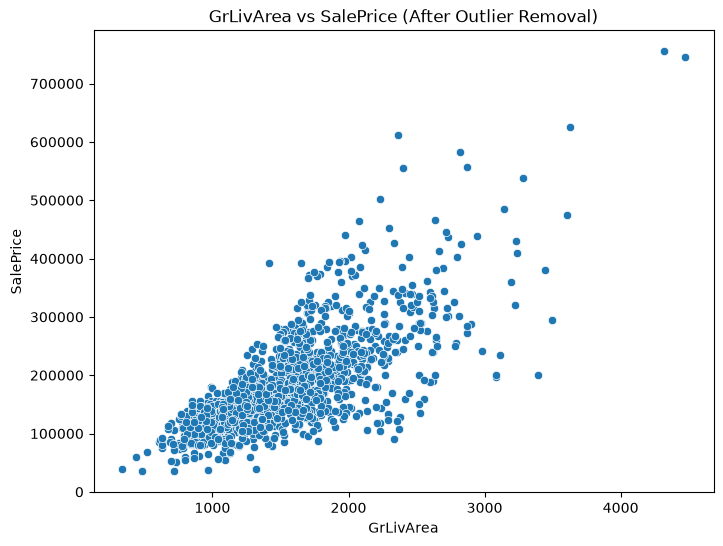

In [49]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'])
plt.title('GrLivArea vs SalePrice (After Outlier Removal)')
plt.savefig('../reports/figures/outliers_removed.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Combining test+train and handling the missing values
y = train['SalePrice']
train_features = train.drop(columns=['SalePrice'])

all_data = pd.concat([train_features,test],axis=0,ignore_index=True)
print("Combined shape: ",all_data.shape)

Combined shape:  (2917, 80)


In [15]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']

for col in none_cols:
    all_data[col] = all_data[col].fillna('None')

In [16]:
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
all_data['GarageYrBlt'] = all_data['GarageYrBlt'].fillna(0)
all_data['MasVnrArea'] = all_data['MasVnrArea'].fillna(0)
all_data['Electrical'] = all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])

In [17]:
remaining_missing = all_data.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
print(remaining_missing)

MSZoning        4
Utilities       2
BsmtFullBath    2
BsmtHalfBath    2
Functional      2
Exterior2nd     1
Exterior1st     1
BsmtUnfSF       1
BsmtFinSF2      1
BsmtFinSF1      1
TotalBsmtSF     1
KitchenQual     1
GarageCars      1
GarageArea      1
SaleType        1
dtype: int64


In [18]:
cat_cols = ['MSZoning', 'Utilities', 'Functional', 'Exterior2nd', 'Exterior1st',
            'KitchenQual', 'SaleType']

for col in cat_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

num_cols = ['BsmtFullBath', 'BsmtHalfBath', 'BsmtUnfSF', 'BsmtFinSF2',
            'BsmtFinSF1', 'TotalBsmtSF', 'GarageCars', 'GarageArea']

for col in num_cols:
    all_data[col] = all_data[col].fillna(0)

In [19]:
remaining_missing = all_data.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print(remaining_missing)
print("\nTotal missing values:", all_data.isnull().sum().sum())

Series([], dtype: int64)

Total missing values: 0


## Feature Engineering

In [20]:
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']

all_data['YearsSinceRemodel'] = all_data['YrSold'] - all_data['YearRemodAdd']

all_data['TotalBath'] = (all_data['FullBath'] + (0.5 * all_data['HalfBath']) +
                          all_data['BsmtFullBath'] + (0.5 * all_data['BsmtHalfBath']))

all_data['WasRemodeled'] = (all_data['YearBuilt'] != all_data['YearRemodAdd']).astype(int)

all_data['IsNew'] = (all_data['YrSold'] == all_data['YearBuilt']).astype(int)

all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)

all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBsmt'] = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)

print("New shape after feature engineering:", all_data.shape)

New shape after feature engineering: (2917, 90)


In [21]:
check_df = all_data.iloc[:len(y)].copy()
check_df['SalePrice'] = y.values

new_features = ['TotalSF', 'HouseAge', 'YearsSinceRemodel', 'TotalBath', 
                 'WasRemodeled', 'IsNew', 'HasPool', 'HasGarage', 'HasBsmt', 'HasFireplace']

check_df[new_features + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)

SalePrice            1.000000
TotalSF              0.832877
TotalBath            0.635896
HasFireplace         0.472350
HasGarage            0.236883
IsNew                0.228954
HasBsmt              0.152860
HasPool              0.103995
WasRemodeled        -0.022155
YearsSinceRemodel   -0.509706
HouseAge            -0.524067
Name: SalePrice, dtype: float64

##### The engineered feature acheived a correlation of 0.83 with SalePrice, So Domain-driven feature Engineering strengthened the predictive signal available to the model.

In [22]:
# Log tranform the target SalePrice
y_log = np.log1p(y)
numeric_feats = all_data.select_dtypes(include=[np.number]).columns
skewed_feats = all_data[numeric_feats].apply(lambda x: x.skew()).sort_values(ascending=False)
high_skew = skewed_feats[abs(skewed_feats)>0.75]
print("Number of skewed features to transform: ",len(high_skew))
print(high_skew)

Number of skewed features to transform:  26
MiscVal          21.950962
PoolArea         17.697766
HasPool          15.502729
LotArea          13.116240
LowQualFinSF     12.090757
3SsnPorch        11.377932
IsNew             4.759378
KitchenAbvGr      4.302763
BsmtFinSF2        4.146636
EnclosedPorch     4.004404
ScreenPorch       3.947131
BsmtHalfBath      3.932018
MasVnrArea        2.623068
OpenPorchSF       2.530660
WoodDeckSF        1.845741
MSSubClass        1.375838
1stFlrSF          1.257933
LotFrontage       1.103606
GrLivArea         1.069300
TotalSF           1.009676
BsmtFinSF1        0.981149
BsmtUnfSF         0.920161
2ndFlrSF          0.861999
GarageYrBlt      -3.906642
HasGarage        -3.941480
HasBsmt          -5.829823
dtype: float64


In [23]:
binary_flags = ['HasPool', 'IsNew', 'HasGarage', 'HasBsmt', 'WasRemodeled', 
                 'BsmtHalfBath', 'KitchenAbvGr']

skewed_to_transform = [col for col in high_skew.index if col not in binary_flags]
print("Features to log-transform:", len(skewed_to_transform))
print(skewed_to_transform)

for col in skewed_to_transform:
    all_data[col] = np.log1p(all_data[col])

Features to log-transform: 20
['MiscVal', 'PoolArea', 'LotArea', 'LowQualFinSF', '3SsnPorch', 'BsmtFinSF2', 'EnclosedPorch', 'ScreenPorch', 'MasVnrArea', 'OpenPorchSF', 'WoodDeckSF', 'MSSubClass', '1stFlrSF', 'LotFrontage', 'GrLivArea', 'TotalSF', 'BsmtFinSF1', 'BsmtUnfSF', '2ndFlrSF', 'GarageYrBlt']


In [24]:
new_skew = all_data[skewed_to_transform].apply(lambda x: x.skew()).sort_values(ascending=False)
print(new_skew)

PoolArea         15.631314
3SsnPorch         8.826656
LowQualFinSF      8.559041
MiscVal           5.214687
ScreenPorch       2.946085
BsmtFinSF2        2.462526
EnclosedPorch     1.960960
MasVnrArea        0.538731
2ndFlrSF          0.306786
MSSubClass        0.246056
WoodDeckSF        0.159605
1stFlrSF          0.030374
GrLivArea        -0.022062
OpenPorchSF      -0.041559
TotalSF          -0.429691
LotArea          -0.532920
BsmtFinSF1       -0.616808
LotFrontage      -1.069010
BsmtUnfSF        -2.155250
GarageYrBlt      -3.926404
dtype: float64


In [25]:
#Encoding the categorical variables
print("Categorical columns: ",all_data.select_dtypes(include='str').shape[1])
all_data_encoded = pd.get_dummies(all_data, drop_first=True)
print("Shape after encoding: ",all_data_encoded.shape)

Categorical columns:  43
Shape after encoding:  (2917, 269)


In [26]:
# Split back into test and train using original row counts
x_train = all_data_encoded.iloc[:len(y),:]
x_test = all_data_encoded.iloc[len(y):,:]

print("x_train shape: ",x_train.shape)
print("x_test shape: ",x_test.shape)
print("y_log shape: ",y_log.shape)

x_train shape:  (1458, 269)
x_test shape:  (1459, 269)
y_log shape:  (1458,)


In [27]:
# Save test IDs for the final file
test_ids = x_test['Id']
X_train = x_train.drop(columns=['Id'])
X_test = x_test.drop(columns=['Id'])

print("Final X_train shape:", x_train.shape)
print("Final X_test shape:", x_test.shape)

Final X_train shape: (1458, 269)
Final X_test shape: (1459, 269)


In [55]:
# Save the fully cleaned data
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_log.to_csv('../data/processed/y_train_log.csv', index=False)

y.to_csv('../data/processed/y_train_actual.csv', index=False)

print("Processed data saved to data/processed/")

Processed data saved to data/processed/


# Modelling

In [28]:
# Train/validation split
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(X_train,y_log,test_size = 0.2,random_state=42)
print("Train: ",X_tr.shape, "Validation: ",X_val.shape)

Train:  (1166, 268) Validation:  (292, 268)


In [29]:
# Evaluation Helper Function
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {}

def evaluate_model(name, model, X_tr, y_tr, X_val, y_val):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae = mean_absolute_error(y_val, preds)
    r2 = r2_score(y_val, preds)
    
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"{name} -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    return model

### Model 1: Linear Regression

In [30]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr_model = evaluate_model("Linear Regression", lr, X_tr, y_tr, X_val, y_val)

Linear Regression -> RMSE: 0.1344, MAE: 0.0881, R2: 0.8928


### Model 2: Ridge

In [31]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=10)
ridge_model = evaluate_model("Ridge", ridge, X_tr, y_tr, X_val, y_val)

Ridge -> RMSE: 0.1198, MAE: 0.0821, R2: 0.9149


### Model 3: Lasso

In [32]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001,max_iter = 50000)
lasso_model = evaluate_model("Lasso", lasso, X_tr, y_tr, X_val, y_val)

Lasso -> RMSE: 0.1194, MAE: 0.0820, R2: 0.9154


### Model 4: Random Forest

In [33]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_model = evaluate_model("Random Forest", rf, X_tr, y_tr, X_val, y_val)

Random Forest -> RMSE: 0.1474, MAE: 0.0984, R2: 0.8712


### Model 5: XGBRegressor

In [34]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42)
xgb_model = evaluate_model("XGBoost", xgb, X_tr, y_tr, X_val, y_val)

XGBoost -> RMSE: 0.1276, MAE: 0.0871, R2: 0.9035


### Model 6: Optuna

In [35]:
import optuna
from sklearn.metrics import mean_squared_error

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        'random_state': 42
    }
    model = XGBRegressor(**params)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

[I 2026-07-20 00:04:02,331] A new study created in memory with name: no-name-b5aedd57-7993-46eb-b98e-0fe4e2ce5238
[I 2026-07-20 00:04:04,166] Trial 0 finished with value: 0.13704353891102022 and parameters: {'n_estimators': 813, 'max_depth': 3, 'learning_rate': 0.019095557951466748, 'subsample': 0.9658753363936514, 'colsample_bytree': 0.6753164295759088, 'reg_alpha': 4.786534964400493, 'reg_lambda': 3.1955626700021904}. Best is trial 0 with value: 0.13704353891102022.
[I 2026-07-20 00:04:05,060] Trial 1 finished with value: 0.12309642227393311 and parameters: {'n_estimators': 443, 'max_depth': 2, 'learning_rate': 0.05701489782030658, 'subsample': 0.848846464826462, 'colsample_bytree': 0.7803043990614604, 'reg_alpha': 1.124520564812178, 'reg_lambda': 1.50419329374254}. Best is trial 1 with value: 0.12309642227393311.
[I 2026-07-20 00:04:05,865] Trial 2 finished with value: 0.18511797516086767 and parameters: {'n_estimators': 388, 'max_depth': 2, 'learning_rate': 0.00544841797022904, 'su

Best RMSE: 0.11838597355781508
Best params: {'n_estimators': 556, 'max_depth': 2, 'learning_rate': 0.03655649215704752, 'subsample': 0.6539736614625533, 'colsample_bytree': 0.6535070449684575, 'reg_alpha': 0.279019739822658, 'reg_lambda': 0.3707947143513106}


### Train final tuned XGBoost model

In [36]:
best_params = study.best_params
best_params['random_state'] = 42

xgb_tuned = XGBRegressor(**best_params)
xgb_tuned_model = evaluate_model("XGBoost (Tuned)", xgb_tuned, X_tr, y_tr, X_val, y_val)

XGBoost (Tuned) -> RMSE: 0.1184, MAE: 0.0829, R2: 0.9169


### Meta-Model: Ridge + Lasso + XGBoost tuned 

In [37]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge as MetaRidge

base_models = [
    ('ridge', Ridge(alpha=10)),
    ('lasso', Lasso(alpha=0.001, max_iter=50000)),
    ('xgb', XGBRegressor(**best_params))
]

stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=MetaRidge(alpha=1.0),
    cv=5  # 5-fold cross-validation to generate meta-features, avoids overfitting
)

stack_final = evaluate_model("Stacked Ensemble", stack_model, X_tr, y_tr, X_val, y_val)

Stacked Ensemble -> RMSE: 0.1154, MAE: 0.0786, R2: 0.9211


### Comparison table between the models

                     RMSE     MAE      R2
Stacked Ensemble   0.1154  0.0786  0.9211
XGBoost (Tuned)    0.1184  0.0829  0.9169
Lasso              0.1194  0.0820  0.9154
Ridge              0.1198  0.0821  0.9149
XGBoost            0.1276  0.0871  0.9035
Linear Regression  0.1344  0.0881  0.8928
Random Forest      0.1474  0.0984  0.8712


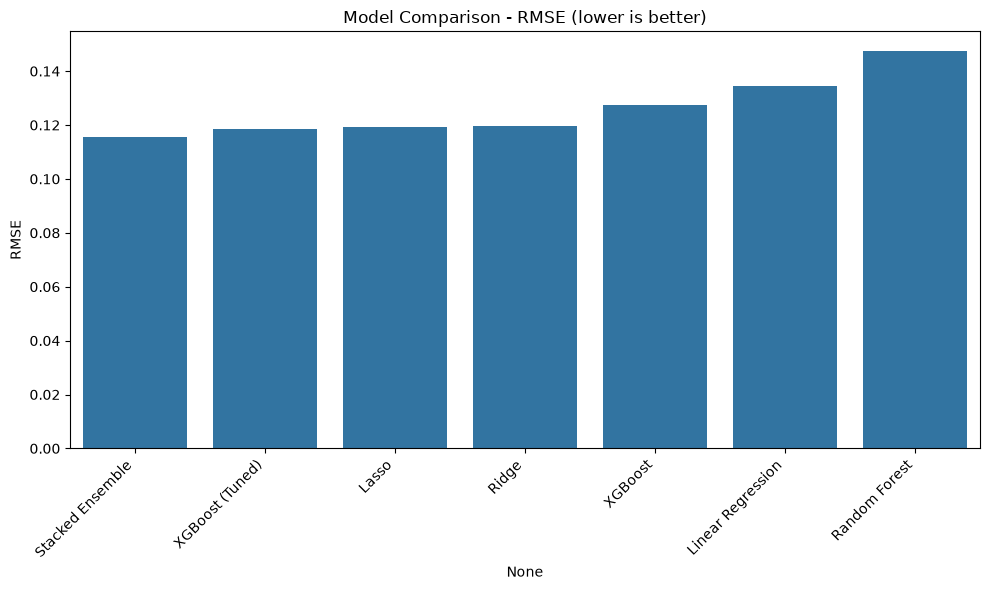

In [50]:
results_df = pd.DataFrame(results).T.sort_values('RMSE')
results_df['RMSE'] = results_df['RMSE'].round(4)
results_df['MAE'] = results_df['MAE'].round(4)
results_df['R2'] = results_df['R2'].round(4)
print(results_df)

plt.figure(figsize=(10,6))
sns.barplot(x=results_df.index, y=results_df['RMSE'])
plt.xticks(rotation=45, ha='right')
plt.title('Model Comparison - RMSE (lower is better)')
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#####  The table shown is well-ordered, all metrics are consistent, and the concludes that it (linear models > untuned trees > tuned trees > ensemble) is coherent and defensible.

### Shap Differentiator

In [39]:
import shap

explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_val)

print("SHAP values computed for", X_val.shape[0], "validation samples")

SHAP values computed for 292 validation samples


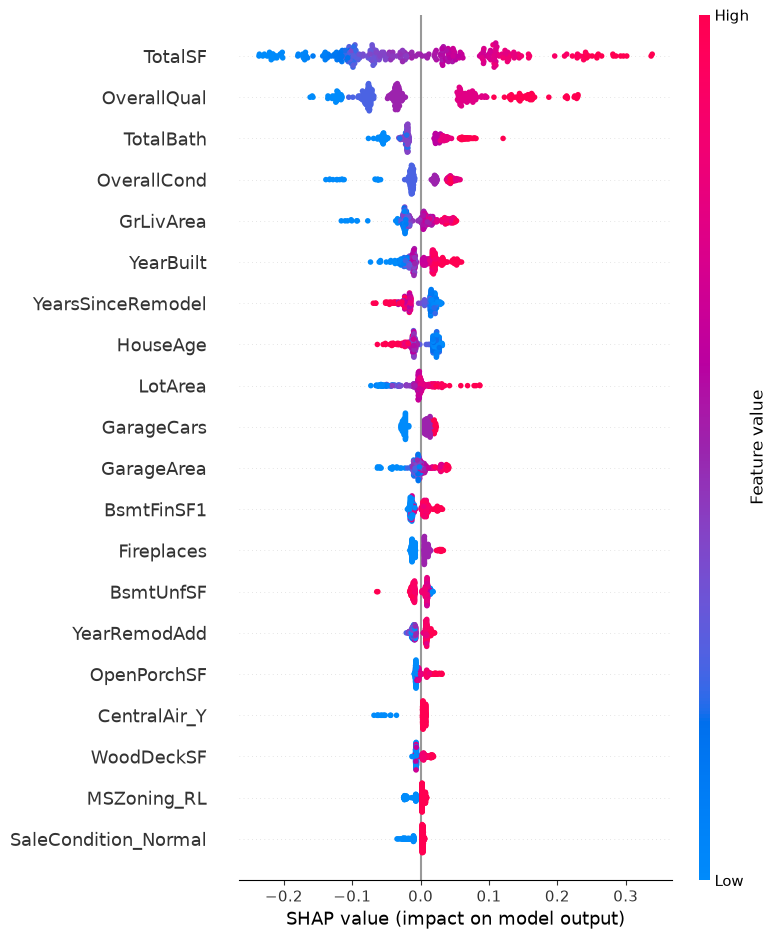

<Figure size 640x480 with 0 Axes>

In [52]:
shap.summary_plot(shap_values, X_val, show=True)
plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

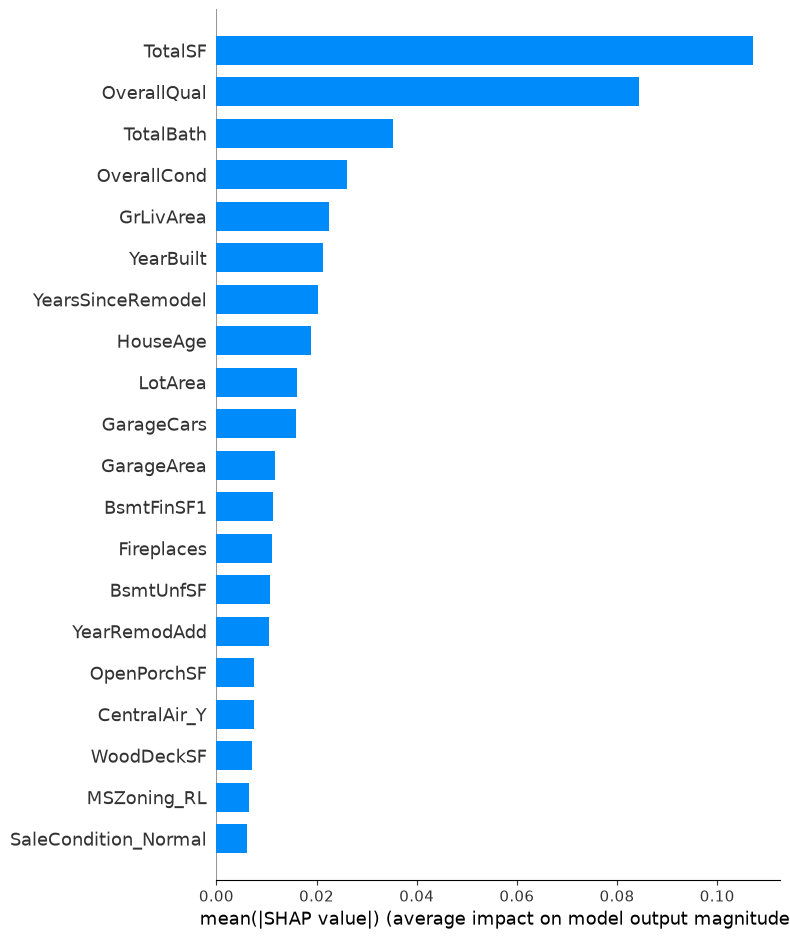

<Figure size 640x480 with 0 Axes>

In [53]:
shap.summary_plot(shap_values, X_val, plot_type='bar', show=True)
plt.savefig('../reports/figures/shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

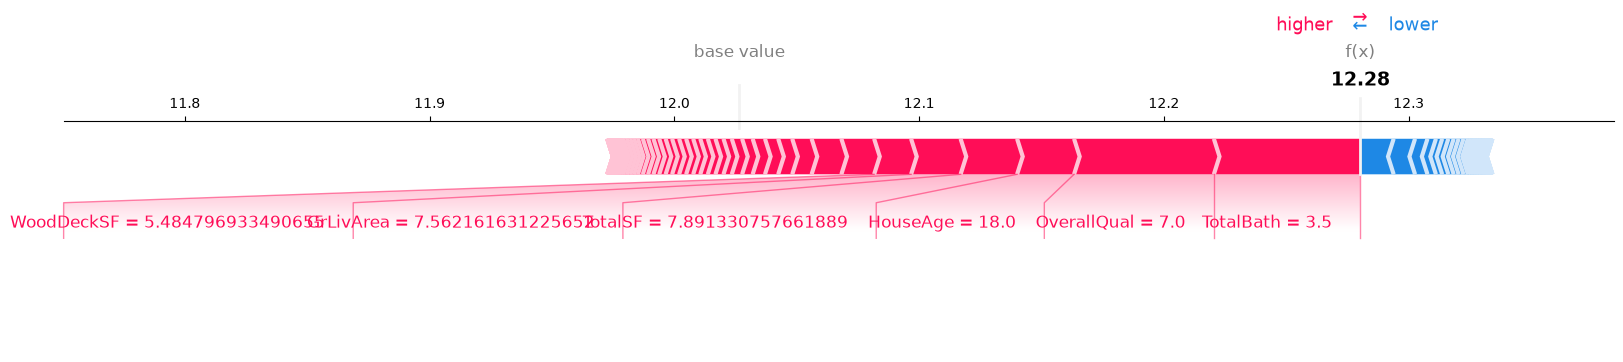

<Figure size 640x480 with 0 Axes>

In [54]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_val.iloc[0], matplotlib=True)
plt.savefig('../reports/figures/shap_importace.png', dpi=150, bbox_inches='tight')
plt.show()

##### SHAP analysis confirmed TotalSF and OverallQual as the dominant drivers of predicted SalePrice.Individual-level SHAP force plots further demonstrated the model's transparency by decomposing single predictions into per-feature contributions, addressing the black-box limitation commonly associated with tree-based ensembles.

In [43]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(stack_model, '../models/best_model.pkl')

joblib.dump(X_train.columns.tolist(), '../models/model_columns.pkl')

print("Model and columns saved successfully!")

Model and columns saved successfully!


In [44]:
stack_model_final = StackingRegressor(
    estimators=base_models,
    final_estimator=MetaRidge(alpha=1.0),
    cv=5
)
stack_model_final.fit(X_train, y_log)

joblib.dump(stack_model_final, '../models/best_model.pkl')
print("Final model (trained on full data) saved!")

Final model (trained on full data) saved!


In [45]:
loaded_model = joblib.load('../models/best_model.pkl')
loaded_columns = joblib.load('../models/model_columns.pkl')

test_pred_log = loaded_model.predict(X_train.iloc[[0]])
test_pred_actual = np.expm1(test_pred_log)  

print("Predicted price (log):", test_pred_log[0])
print("Predicted price ($):", round(test_pred_actual[0], 2))
print("Actual price ($):", round(np.expm1(y_log.iloc[0]), 2))

Predicted price (log): 12.248786245197884
Predicted price ($): 208726.79
Actual price ($): 208500.0
